# Fase 5 — Clusters × Resultado nas Urnas (Desafio pós-eleição)

O TSE divulgou o resultado eleitoral em `DS_SIT_TOT_TURNO`. Aqui investigamos se há **associação entre os 4 clusters construídos na Fase 2** (Base Simbólica, Estruturados, Financiados, Patrimônio Sem Campanha) e o **resultado nas urnas** dos candidatos a Deputado Federal no Nordeste.

**Os clusters não são refeitos**: usamos exatamente as atribuições salvas pelo notebook 02.

## Hipóteses do grupo
- **H0:** o cluster e o resultado são independentes.
- **H1:** há associação. Esperamos que os **Estruturados** sejam os mais eleitos e a **Base Simbólica** a menos eleita.

## Plano
1. Tabela de contingência e descritiva.
2. Análise principal (binária): **Eleito** (QP + Média) × **Não eleito**. Nenhum candidato é excluído, então `#NULO` (candidaturas sem votação válida) conta como não eleito.
3. Qui-quadrado, resíduos padronizados e **V de Cramér**.
4. **Teste de permutação** (p-valor empírico) e IC bootstrap para o V.
5. Análise secundária com Suplente e `#NULO` como categorias próprias.
6. Interpretação e limitações (associação ≠ causalidade).

In [1]:
import warnings
warnings.filterwarnings("ignore")
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style("whitegrid")
pd.set_option('display.max_columns', None)
os.makedirs('images/notebook5', exist_ok=True)

SEMENTE = 42
N_PERM = 10_000
rng = np.random.default_rng(SEMENTE)

ORDEM = ['Estruturados', 'Financiados', 'Base Simbólica', 'Patrimônio Sem Campanha']
CORES = {'Base Simbólica': '#2b5c8f', 'Estruturados': '#74c476',
         'Financiados': '#e6550d', 'Patrimônio Sem Campanha': '#756bb1'}

## 1) Carga dos dados

Lemos o CSV gerado pelos notebooks 00 (resultado eleitoral) e 02 (clusters).

In [2]:
df = pd.read_csv('dados/candidatos_DEPUTADO_FEDERAL_nordeste_2026.csv')
print(f"{df.shape[0]} candidatos x {df.shape[1]} colunas")
assert df['cluster'].notna().all() and df['DS_SIT_TOT_TURNO'].notna().all()
assert df['SQ_CANDIDATO'].is_unique

print("\nResultado oficial (DS_SIT_TOT_TURNO):")
print(df['DS_SIT_TOT_TURNO'].value_counts())
print("\nClusters:")
print(df['cluster'].value_counts())

2224 candidatos x 71 colunas

Resultado oficial (DS_SIT_TOT_TURNO):
DS_SIT_TOT_TURNO
SUPLENTE            983
NÃO ELEITO          944
#NULO               147
ELEITO POR QP       108
ELEITO POR MÉDIA     42
Name: count, dtype: int64

Clusters:
cluster
Estruturados               1153
Financiados                 464
Base Simbólica              359
Patrimônio Sem Campanha     248
Name: count, dtype: int64


## 2) Variável de resultado

| `DS_SIT_TOT_TURNO` | `RESULTADO_3` | `ELEITO` (binária) |
|---|---|---|
| ELEITO POR QP / ELEITO POR MÉDIA | Eleito | Eleito |
| SUPLENTE | Suplente | Não eleito |
| NÃO ELEITO | Não eleito | Não eleito |
| #NULO | #NULO | Não eleito |

Suplentes não assumem o mandato por voto direto e `#NULO` não teve votação válida. Por isso ambos entram como "não eleito" na análise binária. Na secundária eles aparecem separados.

In [3]:
mapa_bin = {'ELEITO POR QP': 'Eleito', 'ELEITO POR MÉDIA': 'Eleito', 'ELEITO': 'Eleito'}
df['ELEITO'] = df['DS_SIT_TOT_TURNO'].map(mapa_bin).fillna('Não eleito')

mapa_4 = {'ELEITO POR QP': 'Eleito', 'ELEITO POR MÉDIA': 'Eleito', 'ELEITO': 'Eleito',
          'SUPLENTE': 'Suplente', 'NÃO ELEITO': 'Não eleito', '#NULO': '#NULO'}
df['RESULTADO'] = df['DS_SIT_TOT_TURNO'].map(mapa_4)
assert df['RESULTADO'].notna().all()
print(pd.crosstab(df['DS_SIT_TOT_TURNO'], df['ELEITO']))

ELEITO            Eleito  Não eleito
DS_SIT_TOT_TURNO                    
#NULO                  0         147
ELEITO POR MÉDIA      42           0
ELEITO POR QP        108           0
NÃO ELEITO             0         944
SUPLENTE               0         983


## 2.1) Conferência dos nomes dos clusters (sanidade)

Antes de qualquer teste, conferimos se **o nome de cada cluster bate com o seu perfil** de patrimônio e gasto, tal como batizado na Fase 2. Os rótulos A/B/C/D do K-Means são arbitrários, e um nome amarrado à letra errada inverteria todas as conclusões.

In [4]:
perfil = df.groupby('cluster').agg(
    Qtd=('SQ_CANDIDATO', 'count'),
    Bens_mediana=('Total_Bens', 'median'),
    Despesas_mediana=('Total_Despesas_Contratadas', 'median'),
    Pct_sem_despesa=('Total_Despesas_Contratadas', lambda x: (x == 0).mean() * 100),
).loc[ORDEM]
display(perfil.round(1))

# Guardas: o perfil precisa bater com o nome
assert perfil.loc['Estruturados', 'Despesas_mediana'] == perfil['Despesas_mediana'].max()
assert perfil.loc['Base Simbólica', 'Despesas_mediana'] == 0 and perfil.loc['Base Simbólica', 'Bens_mediana'] == 0
assert perfil.loc['Patrimônio Sem Campanha', 'Despesas_mediana'] == 0 and perfil.loc['Patrimônio Sem Campanha', 'Bens_mediana'] > 0
assert perfil.loc['Financiados', 'Despesas_mediana'] > 0 and perfil.loc['Financiados', 'Bens_mediana'] == 0
print('OK: nomes dos clusters coerentes com o perfil.')

,Qtd,Bens_mediana,Despesas_mediana,Pct_sem_despesa
cluster,,,,
Estruturados,1153,400000.0,159709.7,0.0
Financiados,464,0.0,33070.0,0.0
Base Simbólica,359,0.0,0.0,97.5
Patrimônio Sem Campanha,248,140000.0,0.0,96.0


OK: nomes dos clusters coerentes com o perfil.


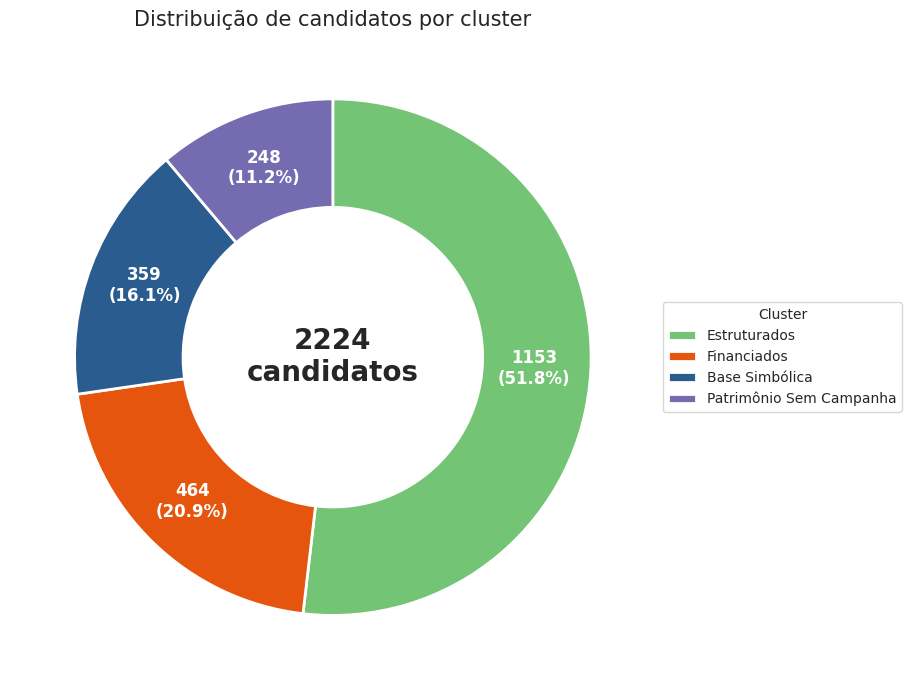

In [5]:
cont = df['cluster'].value_counts().reindex(ORDEM)
fig, ax = plt.subplots(figsize=(9, 7))
wedges, _, autot = ax.pie(cont, colors=[CORES[c] for c in cont.index], startangle=90, counterclock=False,
                          autopct=lambda p: f'{p * cont.sum() / 100:.0f}\n({p:.1f}%)', pctdistance=0.78,
                          wedgeprops=dict(width=0.42, edgecolor='white', linewidth=2),
                          textprops=dict(color='white', fontweight='bold', fontsize=12))
ax.text(0, 0, f'{cont.sum()}\ncandidatos', ha='center', va='center', fontsize=20, fontweight='bold')
ax.legend(wedges, cont.index, title='Cluster', loc='center left', bbox_to_anchor=(1, 0.5))
ax.set_title('Distribuição de candidatos por cluster', fontsize=15)
plt.tight_layout(); plt.savefig('images/notebook5/00_distribuicao_clusters_donut.png', dpi=300, bbox_inches='tight'); plt.show()

## 2.2) Quantidade de candidatos por resultado e cluster

Barras empilhadas com o total de cada resultado, seguidas da tabela correspondente.

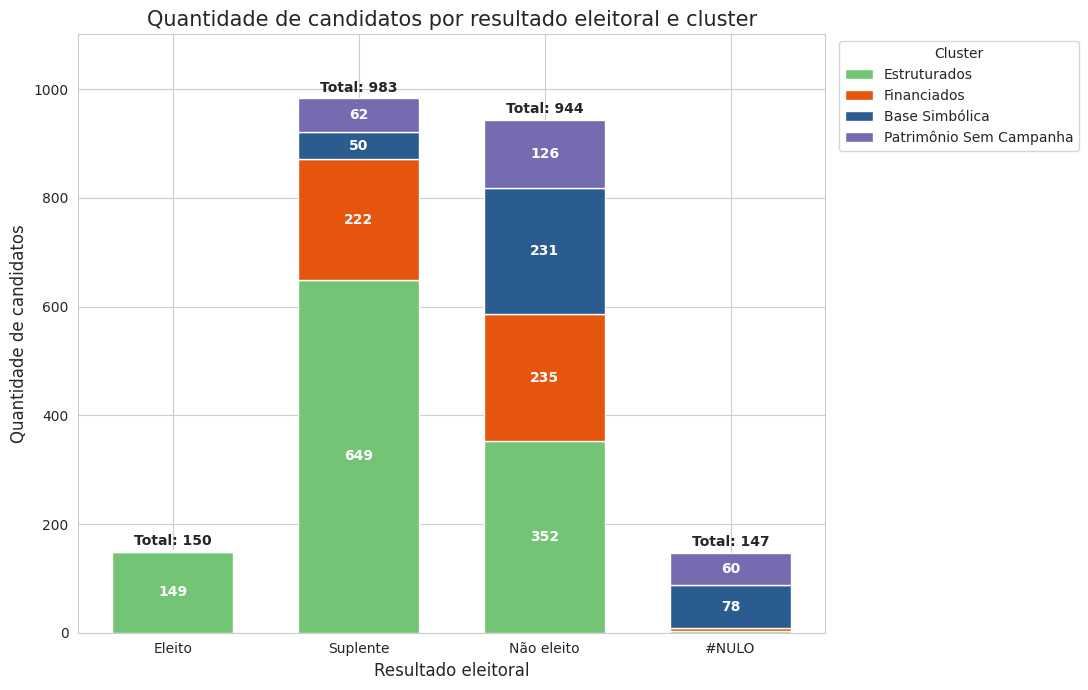

cluster,Estruturados,Financiados,Base Simbólica,Patrimônio Sem Campanha,Total
RESULTADO,,,,,
Eleito,149,1,0,0,150
Suplente,649,222,50,62,983
Não eleito,352,235,231,126,944
#NULO,3,6,78,60,147


In [6]:
ORD_RES = ['Eleito', 'Suplente', 'Não eleito', '#NULO']
q = pd.crosstab(df['RESULTADO'], df['cluster']).reindex(index=ORD_RES, columns=ORDEM)
fig, ax = plt.subplots(figsize=(11, 7))
base = np.zeros(len(q))
for cl in ORDEM:
    vals = q[cl].to_numpy()
    ax.bar(q.index, vals, bottom=base, color=CORES[cl], label=cl, width=0.65, edgecolor='white')
    for i, v in enumerate(vals):
        if v >= 0.03 * q.sum(axis=1).max():
            ax.text(i, base[i] + v / 2, int(v), ha='center', va='center', color='white', fontweight='bold')
    base += vals
for i, tot in enumerate(q.sum(axis=1)):
    ax.text(i, tot + 12, f'Total: {tot}', ha='center', fontweight='bold')
ax.set_ylim(0, q.sum(axis=1).max() * 1.12)
ax.set_xlabel('Resultado eleitoral', fontsize=12); ax.set_ylabel('Quantidade de candidatos', fontsize=12)
ax.set_title('Quantidade de candidatos por resultado eleitoral e cluster', fontsize=15)
ax.legend(title='Cluster', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout(); plt.savefig('images/notebook5/01a_quantidade_resultado_cluster.png', dpi=300, bbox_inches='tight'); plt.show()
display(q.assign(Total=q.sum(axis=1)).rename_axis('RESULTADO'))

## 2.3) Resultados dentro de cada cluster × clusters dentro de cada resultado

À esquerda, o **destino** de cada cluster (soma 100% por barra de cluster). À direita, a **composição** de cada resultado (soma 100% por barra de resultado).

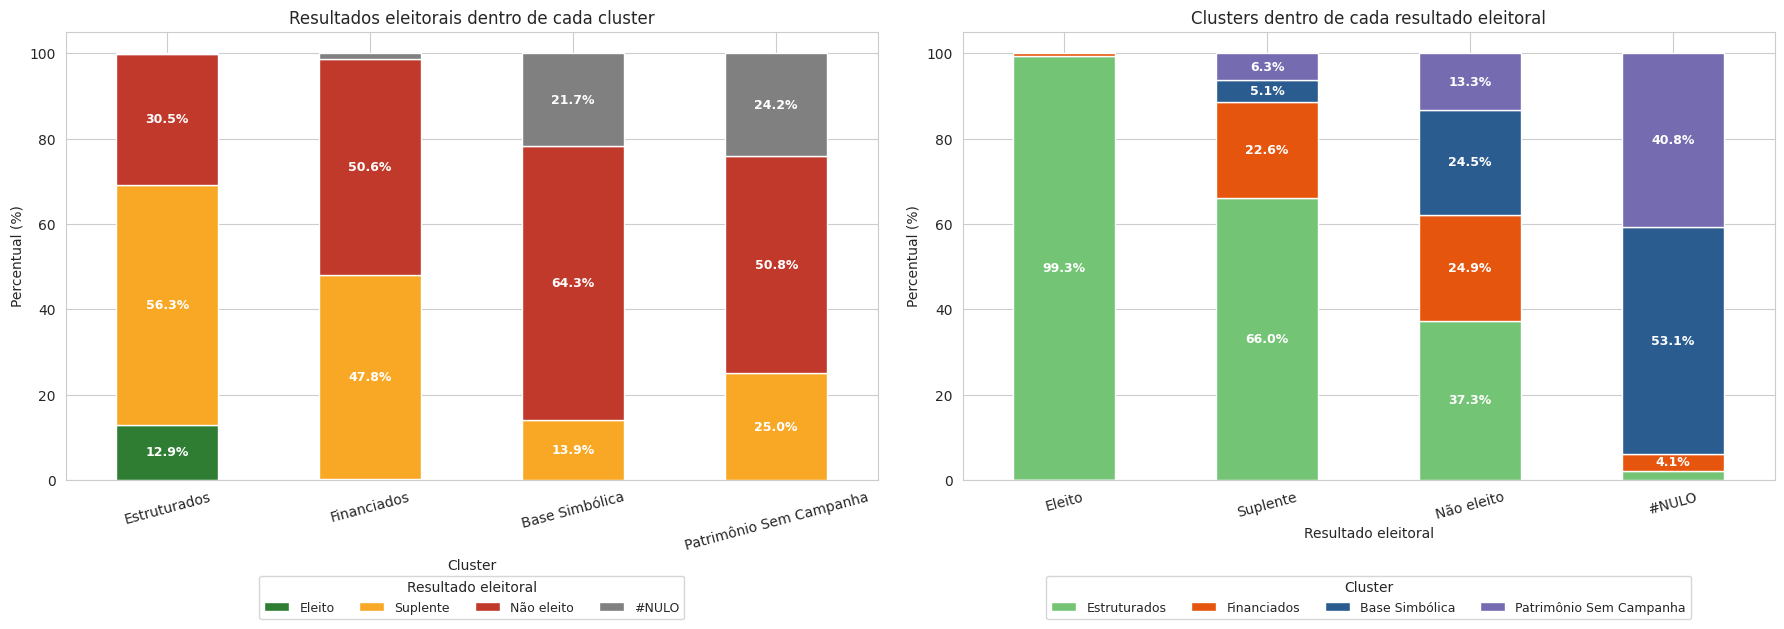

In [7]:
CORES_RES = {'Eleito': '#2e7d32', 'Suplente': '#f9a825', 'Não eleito': '#c0392b', '#NULO': '#808080'}
res_in_cl = pd.crosstab(df['cluster'], df['RESULTADO'], normalize='index').reindex(index=ORDEM, columns=ORD_RES) * 100
cl_in_res = pd.crosstab(df['RESULTADO'], df['cluster'], normalize='index').reindex(index=ORD_RES, columns=ORDEM) * 100

fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))
res_in_cl.plot(kind='bar', stacked=True, ax=axes[0], color=[CORES_RES[c] for c in ORD_RES], width=0.5)
axes[0].set_title('Resultados eleitorais dentro de cada cluster'); axes[0].set_xlabel('Cluster'); axes[0].set_ylabel('Percentual (%)')
axes[0].legend(title='Resultado eleitoral', loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4, fontsize=9); axes[0].tick_params(axis='x', rotation=15)
cl_in_res.plot(kind='bar', stacked=True, ax=axes[1], color=[CORES[c] for c in ORDEM], width=0.5)
axes[1].set_title('Clusters dentro de cada resultado eleitoral'); axes[1].set_xlabel('Resultado eleitoral'); axes[1].set_ylabel('Percentual (%)')
axes[1].legend(title='Cluster', loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=4, fontsize=9); axes[1].tick_params(axis='x', rotation=15)
for ax in axes:
    for cont_ in ax.containers:
        ax.bar_label(cont_, labels=[f'{v:.1f}%' if v >= 3 else '' for v in cont_.datavalues],
                     label_type='center', color='white', fontweight='bold', fontsize=9)
plt.tight_layout(); plt.savefig('images/notebook5/01b_percentuais_cruzados.png', dpi=300, bbox_inches='tight'); plt.show()

## 3) Tabela de contingência (análise principal: Eleito × Não eleito)

In [8]:
ct = pd.crosstab(df['cluster'], df['ELEITO']).loc[ORDEM, ['Eleito', 'Não eleito']]
ct_pct = (ct.div(ct.sum(axis=1), axis=0) * 100).round(1)
print("Contagens:"); display(ct.assign(Total=ct.sum(axis=1)))
print("% por cluster (linha):"); display(ct_pct)
print(f"Taxa geral de eleição: {ct['Eleito'].sum() / ct.values.sum() * 100:.1f}%")

Contagens:


ELEITO,Eleito,Não eleito,Total
cluster,,,
Estruturados,149,1004,1153
Financiados,1,463,464
Base Simbólica,0,359,359
Patrimônio Sem Campanha,0,248,248


% por cluster (linha):


ELEITO,Eleito,Não eleito
cluster,,
Estruturados,12.9,87.1
Financiados,0.2,99.8
Base Simbólica,0.0,100.0
Patrimônio Sem Campanha,0.0,100.0


Taxa geral de eleição: 6.7%


## 4) Análise principal: qui-quadrado e V de Cramér (4 × 2)

Teste de independência de Pearson. O V de Cramér mede a **força** da associação (0 a 1), pois o χ² cresce com o tamanho da amostra:

$$V = \sqrt{\frac{\chi^2}{n \cdot \min(r-1,\, c-1)}}$$

Referência de Cohen (para gl* = min(r−1, c−1) = 1): V ≈ 0,10 pequeno, 0,30 médio, 0,50 grande. Com gl* = 2, os limites são ≈ 0,07, 0,21 e 0,35. Com gl* = 3, ≈ 0,06, 0,17 e 0,29.

In [9]:
def cramers_v(tabela):
    t = np.asarray(tabela)
    chi2 = stats.chi2_contingency(t, correction=False)[0]
    n = t.sum()
    return np.sqrt(chi2 / (n * (min(t.shape) - 1)))

def teste_qui2(tabela, nome):
    chi2, p, gl, esp = stats.chi2_contingency(tabela, correction=False)
    v = cramers_v(tabela)
    print(f"[{nome}] chi2 = {chi2:.2f} | gl = {gl} | p = {p:.3e} | V de Cramér = {v:.3f} | n = {np.asarray(tabela).sum()}")
    print(f"   menor frequência esperada = {esp.min():.2f}; células com esperado < 5: {(esp < 5).sum()} de {esp.size} ({(esp < 5).mean() * 100:.1f}%)")
    if (esp < 5).any():
        print("   Há frequências esperadas pequenas: o p-valor assintótico é aproximado; use a permutação.")
    return chi2, p, gl, esp, v

chi2_obs, p_obs, gl, esp, v_obs = teste_qui2(ct, 'Principal 4x2')
display(pd.DataFrame(esp, index=ct.index, columns=ct.columns).round(1).rename_axis('Frequências esperadas'))

[Principal 4x2] chi2 = 145.32 | gl = 3 | p = 2.692e-31 | V de Cramér = 0.256 | n = 2224
   menor frequência esperada = 16.73; células com esperado < 5: 0 de 8 (0.0%)


ELEITO,Eleito,Não eleito
Frequências esperadas,,
Estruturados,77.8,1075.2
Financiados,31.3,432.7
Base Simbólica,24.2,334.8
Patrimônio Sem Campanha,16.7,231.3


### 4.1) Resíduos padronizados ajustados: onde está a associação?

Valores com módulo > 1,96 indicam células que se desviam da independência (~5%); > 2,58, ~1%.

ELEITO,Eleito,Não eleito
cluster,,
Estruturados,12.05,-12.05
Financiados,-6.30,6.30
Base Simbólica,-5.56,5.56
Patrimônio Sem Campanha,-4.49,4.49


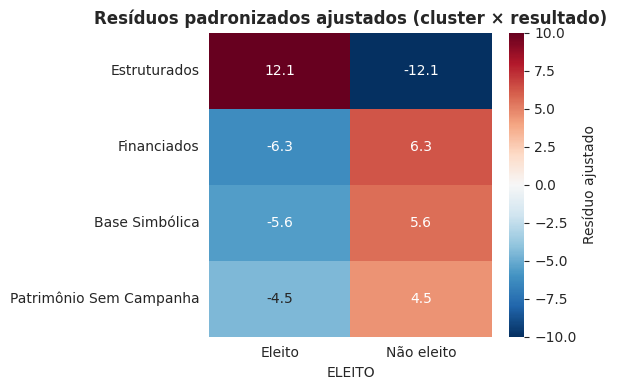

In [10]:
def residuos_ajustados(tabela):
    t = np.asarray(tabela, dtype=float)
    n = t.sum(); lin = t.sum(1, keepdims=True); col = t.sum(0, keepdims=True)
    esp = lin * col / n
    return (t - esp) / np.sqrt(esp * (1 - lin / n) * (1 - col / n))

res_aj = pd.DataFrame(residuos_ajustados(ct), index=ct.index, columns=ct.columns)
display(res_aj.round(2))
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(res_aj, annot=True, fmt='.1f', cmap='RdBu_r', center=0, vmin=-10, vmax=10, ax=ax, cbar_kws={'label': 'Resíduo ajustado'})
ax.set_title('Resíduos padronizados ajustados (cluster × resultado)', fontweight='bold'); ax.set_ylabel('')
plt.tight_layout(); plt.savefig('images/notebook5/02_residuos_ajustados.png', dpi=300, bbox_inches='tight'); plt.show()

## 5) Teste de permutação

Para não depender da aproximação assintótica do χ², embaralhamos os rótulos de resultado entre os candidatos (o que destrói qualquer associação, mantendo as marginais) e recalculamos o χ² **10 000** vezes. O p-valor empírico é $(1 + \#\{\chi^2_{perm} \ge \chi^2_{obs}\}) / (1 + B)$.

chi2 observado = 145.32
chi2 permutado: média = 3.03 | máx = 25.08
p-valor empírico (permutação, B=10000) = 9.999e-05   [mínimo possível = 1.0e-04]
p-valor assintótico = 2.692e-31


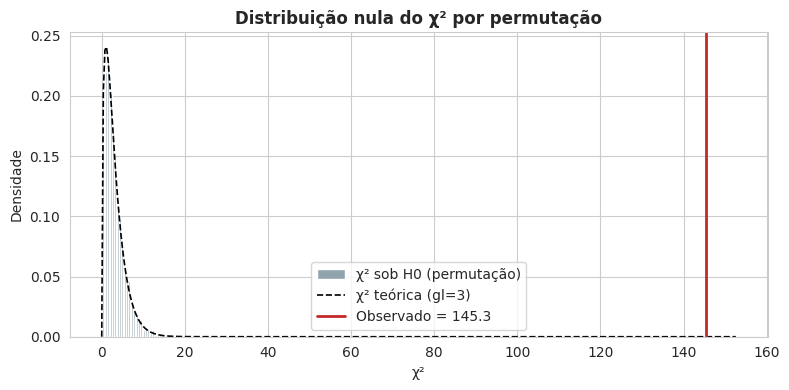

In [11]:
def teste_permutacao(clusters, resultado, n_perm=N_PERM, seed=SEMENTE):
    rng_ = np.random.default_rng(seed)
    cl_codes, _ = pd.factorize(clusters)
    re_codes, _ = pd.factorize(resultado)
    nl, nc = cl_codes.max() + 1, re_codes.max() + 1

    def chi2_de(re):
        t = np.zeros((nl, nc)); np.add.at(t, (cl_codes, re), 1)
        e = t.sum(1, keepdims=True) * t.sum(0, keepdims=True) / t.sum()
        return ((t - e) ** 2 / e).sum()

    obs = chi2_de(re_codes)
    perm = np.array([chi2_de(rng_.permutation(re_codes)) for _ in range(n_perm)])
    p_emp = (1 + (perm >= obs).sum()) / (1 + n_perm)
    return obs, perm, p_emp

obs, perm, p_emp = teste_permutacao(df['cluster'], df['ELEITO'])
print(f"chi2 observado = {obs:.2f}")
print(f"chi2 permutado: média = {perm.mean():.2f} | máx = {perm.max():.2f}")
print(f"p-valor empírico (permutação, B={N_PERM}) = {p_emp:.4g}   [mínimo possível = {1/(1+N_PERM):.1e}]")
print(f"p-valor assintótico = {p_obs:.3e}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm, bins=60, color='#90a4ae', edgecolor='white', density=True, label='χ² sob H0 (permutação)')
xs = np.linspace(0, max(perm.max(), obs) * 1.05, 400)
ax.plot(xs, stats.chi2.pdf(xs, gl), 'k--', lw=1.2, label=f'χ² teórica (gl={gl})')
ax.axvline(obs, color='#c62828', lw=2, label=f'Observado = {obs:.1f}')
ax.set_xlabel('χ²'); ax.set_ylabel('Densidade'); ax.set_title('Distribuição nula do χ² por permutação', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.savefig('images/notebook5/03_permutacao_chi2.png', dpi=300, bbox_inches='tight'); plt.show()

### 5.1) IC bootstrap de 95% para o V de Cramér

In [12]:
rng_b = np.random.default_rng(SEMENTE)
cl = df['cluster'].to_numpy(); el = df['ELEITO'].to_numpy()
vs = []
for _ in range(2000):
    idx = rng_b.integers(0, len(df), len(df))
    t = pd.crosstab(cl[idx], el[idx])
    if t.shape == ct.shape:
        vs.append(cramers_v(t))
ic = np.percentile(vs, [2.5, 97.5])
print(f"V de Cramér = {v_obs:.3f}  (IC95% bootstrap: {ic[0]:.3f} a {ic[1]:.3f})")

V de Cramér = 0.256  (IC95% bootstrap: 0.235 a 0.278)


## 6) Taxa de eleição por cluster (resposta direta às hipóteses)

IC de Wilson de 95% para a proporção de eleitos em cada cluster.

ELEITO,Eleito,n,taxa_%,IC95_inf_%,IC95_sup_%
cluster,,,,,
Estruturados,149,1153,12.9,11.1,15.0
Financiados,1,464,0.2,0.0,1.2
Base Simbólica,0,359,0.0,0.0,1.1
Patrimônio Sem Campanha,0,248,0.0,0.0,1.5


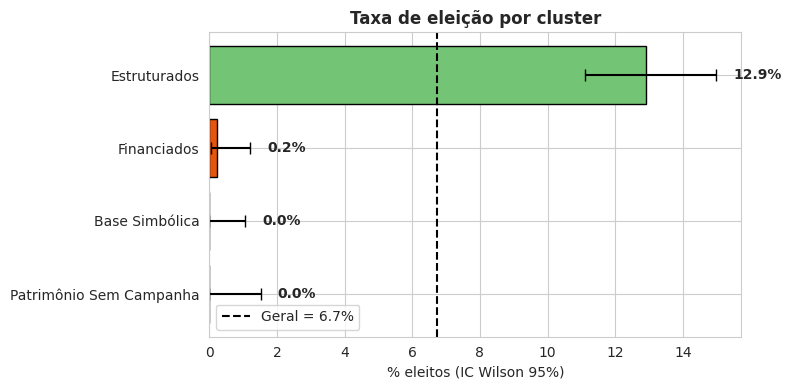

In [13]:
taxa = ct.copy()
taxa['n'] = taxa.sum(axis=1)
taxa['taxa_%'] = taxa['Eleito'] / taxa['n'] * 100
ics = [stats.binomtest(int(k), int(n)).proportion_ci(confidence_level=0.95, method='wilson') for k, n in zip(taxa['Eleito'], taxa['n'])]
taxa['IC95_inf_%'] = [i.low * 100 for i in ics]; taxa['IC95_sup_%'] = [i.high * 100 for i in ics]
display(taxa[['Eleito', 'n', 'taxa_%', 'IC95_inf_%', 'IC95_sup_%']].round(1))

fig, ax = plt.subplots(figsize=(8, 4))
y = np.arange(len(taxa))
ax.barh(y, taxa['taxa_%'], color=[CORES[c] for c in taxa.index], edgecolor='black',
        xerr=[taxa['taxa_%'] - taxa['IC95_inf_%'], taxa['IC95_sup_%'] - taxa['taxa_%']], capsize=4)
ax.set_yticks(y); ax.set_yticklabels(taxa.index); ax.invert_yaxis()
tg = ct['Eleito'].sum() / ct.values.sum() * 100
ax.axvline(tg, color='k', ls='--', label=f'Geral = {tg:.1f}%')
for i, v in enumerate(taxa['taxa_%']): ax.text(taxa['IC95_sup_%'].iloc[i] + 0.5, i, f'{v:.1f}%', va='center', fontweight='bold')
ax.set_xlabel('% eleitos (IC Wilson 95%)'); ax.set_title('Taxa de eleição por cluster', fontweight='bold'); ax.legend()
plt.tight_layout(); plt.savefig('images/notebook5/04_taxa_eleicao.png', dpi=300, bbox_inches='tight'); plt.show()

### 6.1) Comparações par a par (Fisher exato 2×2 com correção de Bonferroni)

Para saber **quais clusters diferem entre si**, comparamos todos os pares. Como há células com contagem zero ou muito baixa (ex.: nenhum Estruturado eleito), o qui-quadrado não é adequado aqui. Usamos o **teste exato de Fisher**. Com 6 pares, o nível ajustado é 0,05 / 6 ≈ 0,0083.

In [14]:
from itertools import combinations
linhas = []
for a, b in combinations(ORDEM, 2):
    sub = ct.loc[[a, b]].to_numpy()
    odds, p_ = stats.fisher_exact(sub)
    linhas.append({'Par': f'{a} × {b}', 'Eleitos A': sub[0, 0], 'n A': sub[0].sum(),
                   'Eleitos B': sub[1, 0], 'n B': sub[1].sum(),
                   'p (Fisher)': p_, 'p Bonferroni': min(p_ * 6, 1)})
pares = pd.DataFrame(linhas).sort_values('p (Fisher)')
display(pares)

,Par,Eleitos A,n A,Eleitos B,n B,p (Fisher),p Bonferroni
0,Estruturados × Financiados,149,1153,1,464,4.185471e-22,2.511283e-21
1,Estruturados × Base Simbólica,149,1153,0,359,3.509357e-19,2.105614e-18
2,Estruturados × Patrimônio Sem Campanha,149,1153,0,248,5.216229e-14,3.129737e-13
3,Financiados × Base Simbólica,1,464,0,359,1.000000e+00,1.000000e+00
4,Financiados × Patrimônio Sem Campanha,1,464,0,248,1.000000e+00,1.000000e+00
5,Base Simbólica × Patrimônio Sem Campanha,0,359,0,248,1.000000e+00,1.000000e+00


## 7) Análise secundária: Eleito × Suplente × Não eleito × #NULO (4 × 4)

Aqui o resultado mantém suas quatro categorias, sem excluir ninguém.

RESULTADO,Eleito,Suplente,Não eleito,#NULO,Total
cluster,,,,,
Estruturados,149,649,352,3,1153
Financiados,1,222,235,6,464
Base Simbólica,0,50,231,78,359
Patrimônio Sem Campanha,0,62,126,60,248


[Secundária 4x4] chi2 = 691.03 | gl = 9 | p = 5.866e-143 | V de Cramér = 0.322 | n = 2224
   menor frequência esperada = 16.39; células com esperado < 5: 0 de 16 (0.0%)


p-valor empírico (permutação, B=10000) = 9.999e-05

Resíduos padronizados ajustados:


RESULTADO,Eleito,Suplente,Não eleito,#NULO
cluster,,,,
Estruturados,12.05,11.91,-11.80,-12.51
Financiados,-6.30,1.78,4.02,-5.18
Base Simbólica,-5.56,-12.61,9.17,12.59
Patrimônio Sem Campanha,-4.49,-6.46,2.83,11.82


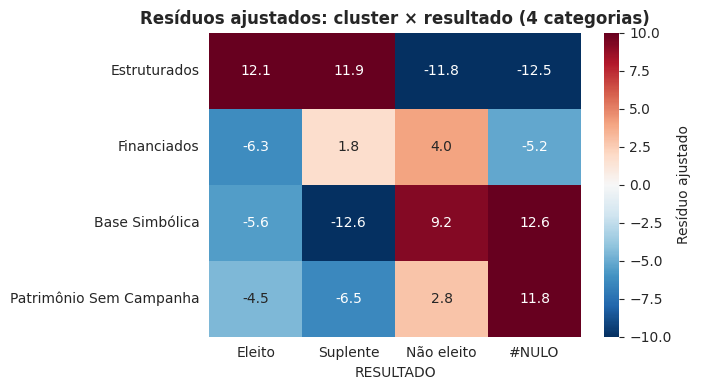

In [15]:
ct4 = pd.crosstab(df['cluster'], df['RESULTADO']).loc[ORDEM, ['Eleito', 'Suplente', 'Não eleito', '#NULO']]
display(ct4.assign(Total=ct4.sum(axis=1)))
chi2_4, p_4, gl_4, esp_4, v_4 = teste_qui2(ct4, 'Secundária 4x4')
obs4, perm4, p_emp4 = teste_permutacao(df['cluster'], df['RESULTADO'])
print(f"p-valor empírico (permutação, B={N_PERM}) = {p_emp4:.4g}")
res4 = pd.DataFrame(residuos_ajustados(ct4), index=ct4.index, columns=ct4.columns)
print("\nResíduos padronizados ajustados:"); display(res4.round(2))
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(res4, annot=True, fmt='.1f', cmap='RdBu_r', center=0, vmin=-10, vmax=10, ax=ax, cbar_kws={'label': 'Resíduo ajustado'})
ax.set_title('Resíduos ajustados: cluster × resultado (4 categorias)', fontweight='bold'); ax.set_ylabel('')
plt.tight_layout(); plt.savefig('images/notebook5/05_residuos_4x4.png', dpi=300, bbox_inches='tight'); plt.show()

## 8) Resumo dos testes

In [16]:
resumo = pd.DataFrame([
    {'Análise': 'Principal (4×2: Eleito × Não eleito)', 'chi2': chi2_obs, 'gl': gl, 'p assintótico': p_obs, 'p permutação': p_emp, 'V de Cramér': v_obs},
    {'Análise': 'Secundária (4×4, 4 categorias)', 'chi2': chi2_4, 'gl': gl_4, 'p assintótico': p_4, 'p permutação': p_emp4, 'V de Cramér': v_4},
])
display(resumo.round(4))

,Análise,chi2,gl,p assintótico,p permutação,V de Cramér
0,Principal (4×2: Eleito × Não eleito),145.3205,3,0.0,0.0001,0.2556
1,"Secundária (4×4, 4 categorias)",691.0289,9,0.0,0.0001,0.3218


## 9) Interpretação

### O que encontramos
- **Há associação estatisticamente significativa** entre cluster e resultado (H0 rejeitada). Principal 4×2: χ² = 145,3 (gl = 3), p < 0,001. A permutação confirma: nas 10 000 permutações o χ² máximo foi ≈ 25, contra 145 observado. O p empírico ≈ 1×10⁻⁴ é o mínimo possível com B = 10 000. Nenhuma célula tem frequência esperada < 5 (0%), então o qui-quadrado é válido mesmo sem a permutação.
- **Força:** V de Cramér = **0,256** (IC95% bootstrap 0,235 a 0,278), entre pequeno e médio na escala de Cohen. Como só 6,7% dos candidatos são eleitos, o V máximo possível nessa tabela é bem menor que 1, então 0,256 é uma associação considerável. Na análise 4×4, V = **0,322** (acima de 0,29, efeito grande para gl* = 3).
- **Onde está a associação (resíduos ajustados):** os **Estruturados** concentram os eleitos (resíduo +12,1; 149 dos 150 eleitos; taxa de eleição de 12,9%, IC95% 11,1% a 15,0%). Financiados (0,2%), Base Simbólica (0%) e Patrimônio Sem Campanha (0%) ficam abaixo do esperado.
- **Pares (Fisher + Bonferroni):** os Estruturados diferem de cada um dos outros três (p ajustado < 10⁻¹³). Os outros três **não diferem entre si**, porque neles praticamente não há eleitos.
- **Análise 4×4:** a Base Simbólica (resíduo +12,6) e o Patrimônio Sem Campanha (+11,8) têm excesso de `#NULO`: 78 de 359 (21,7%) e 60 de 248 (24,2%), contra 0,3% nos Estruturados. Os Estruturados também têm excesso de Suplente (+11,9): ficaram na lista, mas fora das vagas.

### Confronto com as hipóteses do grupo
- **Confirmada:** os Estruturados são os mais eleitos.
- **Confirmada:** a Base Simbólica é a menos eleita (0 eleitos em 359) e a que mais tem candidaturas anuladas (`#NULO`).
- **Ressalva:** Financiados e Patrimônio Sem Campanha também ficaram praticamente sem eleitos. Ter apenas patrimônio ou apenas campanha financiada não bastou. Os eleitos tinham, em geral, as duas coisas (alto patrimônio e alto gasto de campanha).

### Cuidados na leitura
- **Associação não é causalidade.** Os resultados não mostram que gastar mais ou ter mais patrimônio elege alguém. O sentido pode ser inverso, já que candidatos competitivos atraem mais recursos, ou depender de fatores não controlados, como partido, UF, incumbência, popularidade prévia e número de candidatos na legenda.
- **Circularidade parcial:** o cluster usa a despesa de campanha, e candidatos com `#NULO` ou sem votação tendem a ter campanhas encerradas ou inativas, o que os leva ao cluster sem gastos. Parte da associação reflete isso.
- **Independência:** a disputa é por vagas limitadas por UF, então os candidatos não são independentes entre si, o que viola em parte a suposição do qui-quadrado. A permutação ameniza, mas não elimina.
- **Escopo:** a análise cobre apenas Deputado Federal dos 9 estados do Nordeste (151 vagas; 150 eleitos na base, um a menos do que as vagas), como definido no notebook 00, e não o Brasil todo.
- **Atualização da base:** a base pós-eleição tem 35 candidatos a mais do que a usada na Fase 2. Eles receberam cluster ao reexecutar o notebook 02 com seed fixa.
- **Correção importante:** os nomes dos clusters no notebook 02 estavam amarrados às letras A/B/C/D do K-Means, que são arbitrárias. Isso trocava os nomes Estruturados e Base Simbólica. O notebook 02 agora atribui o nome pelo perfil (medianas), e a seção 2.1 deste notebook confere isso com `assert`.